## This code was written by Eric Tellez, Geophysics Institute, UNAM.

I dont know which license Im going to use yet.

# Furuno ODIM H5 Data

### 1. Define the libraries

In [2]:
import wradlib as wrl
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as pl
import numpy as np
try:
    get_ipython().magic("matplotlib inline")
except:
    pl.ion()

### 2. Open the data with Opera HDF5

[HDF5](https://www.hdfgroup.org/HDF5/) is a data model, library, and file format for storing and managing data. The [OPERA 3 program](http://www.eumetnet.eu/opera) developed a convention (or information model) on how to store and exchange radar data in hdf5 format. It is based on the work of [COST Action 717](https://e-services.cost.eu/files/domain_files/METEO/Action_717/final_report/final_report-717.pdf) and is used e.g. in real-time operations in the Nordic European countries. The OPERA Data and Information Model (ODIM) is documented e.g. in this [report](https://www.eol.ucar.edu/system/files/OPERA_2008_03_WP2.1b_ODIM_H5_v2.1.pdf). Make use of these documents in order to understand the organization of OPERA hdf5 files!

<div class="alert alert-warning">

**Note** <br>
    
Since $\omega radlib$ version 1.10 an [OdimH5](https://docs.wradlib.org/en/stable/generated/wradlib.io.xarray.open_odim_dataset.html) reader based on [Xarray](https://xarray.pydata.org) is available. Please read the more indepth notebook [wradlib_odim_backend](wradlib_odim_backend.ipynb).

Former `xarray`-based implementations will be deprecated in future versions.
    
</div>

The hierarchical nature of HDF5 can be described as being similar to directories, files, and links on a hard-drive. Actual metadata are stored as so-called *attributes*, and these attributes are organized together in so-called *groups*. Binary data are stored as so-called *datasets*. As for ODIM_H5, the ``root`` (or top level) group contains three groups of metadata: these are called ``what`` (object, information model version, and date/time information), ``where`` (geographical information), and ``how`` (quality and optional/recommended metadata). For a very simple product, e.g. a CAPPI, the data is organized in a group called ``dataset1`` which contains another group called ``data1`` where the actual binary data are found in ``data``. In analogy with a file system on a hard-disk, the HDF5 file containing this simple product is organized like this:

```
    /
    /what
    /where
    /how
    /dataset1
    /dataset1/data1
    /dataset1/data1/data
```

The philosophy behind the $\omega radlib$ interface to OPERA's data model is very straightforward: $\omega radlib$ simply translates the complete file structure to *one* dictionary and returns this dictionary to the user. Thus, the potential complexity of the stored data is kept and it is left to the user how to proceed with this data. The keys of the output dictionary are strings that correspond to the "directory trees" shown above. Each key ending with ``/data`` points to a Dataset (i.e. a numpy array of data). Each key ending with ``/what``, ``/where`` or ``/how`` points to another dictionary of metadata. The entire output can be obtained by:

In [3]:
fpath = 'radar_data_examples/ODIM_H5/0087_20210911/0087_20210911_171500.h5' # Remember that we already defined the main path
f = wrl.util.get_wradlib_data_file(fpath)
fcontent = wrl.io.read_opera_hdf5(f)

### Remember that the dataset1/data1/data corresponds to elevation_angle/meteorological_parameter/data.
###  dataset1=3.1 and data2=dBz

### dataset#/how contains the elevation angle and the azimuth angle of each measurement and that corresponds to X axis of the reflectivity data with 238 bins

To inspect the data:

In [4]:
# which keywords can be used to access the content?
print(fcontent.keys())
# print the entire content including values of data and metadata
# (numpy arrays will not be entirely printed)
print(fcontent['dataset1/data2/data'])

dict_keys(['dataset1/data1/data', 'dataset1/data1/what', 'dataset1/data2/data', 'dataset1/data2/what', 'dataset1/data3/data', 'dataset1/data3/what', 'dataset1/data4/data', 'dataset1/data4/what', 'dataset1/data5/data', 'dataset1/data5/what', 'dataset1/data6/data', 'dataset1/data6/what', 'dataset1/data7/data', 'dataset1/data7/what', 'dataset1/data8/data', 'dataset1/data8/what', 'dataset1/data9/data', 'dataset1/data9/what', 'dataset1/how', 'dataset1/what', 'dataset1/where', 'dataset2/data1/data', 'dataset2/data1/what', 'dataset2/data2/data', 'dataset2/data2/what', 'dataset2/data3/data', 'dataset2/data3/what', 'dataset2/data4/data', 'dataset2/data4/what', 'dataset2/data5/data', 'dataset2/data5/what', 'dataset2/data6/data', 'dataset2/data6/what', 'dataset2/data7/data', 'dataset2/data7/what', 'dataset2/data8/data', 'dataset2/data8/what', 'dataset2/data9/data', 'dataset2/data9/what', 'dataset2/how', 'dataset2/what', 'dataset2/where', 'dataset3/data1/data', 'dataset3/data1/what', 'dataset3/dat

## To plot a cartesian H5 in polar form

In [5]:
type(fcontent['dataset1/how']) #This is a dictionary
type(fcontent['dataset1/how']['startazA']) #This is an array
type(fcontent['dataset1/data2/data']) #This is an array
type(fcontent['where']) #This is a dictionary

dict

In [6]:
type(fcontent['where']['lon'])

numpy.float64

In [9]:
# Coordinates are always the same
# (longitude,latitude,altitude)
sitio=(-98.65487,19.11921,4007.0)

#  coordinates are in fcontent['where']
sitio=(fcontent['where']['lon'], #This form is more general
       fcontent['where']['lat'],
       fcontent['where']['height'])

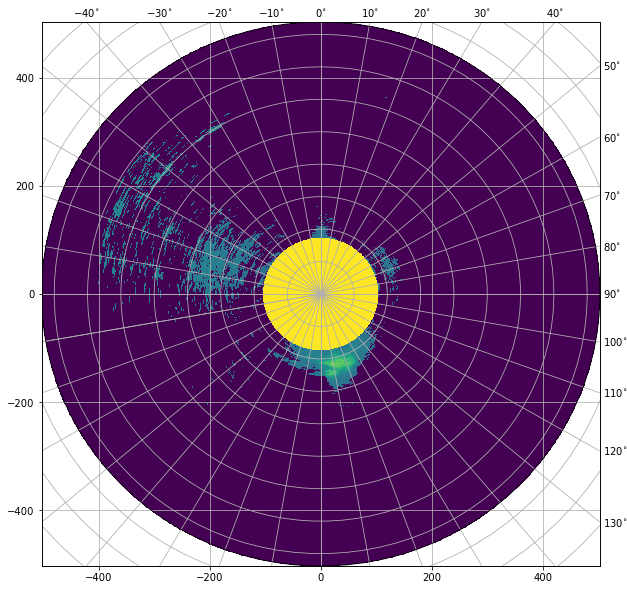

In [18]:
fig = pl.figure(figsize=(10, 10))
im = wrl.vis.plot_ppi(fcontent['dataset1/data2/data'],
                      az=fcontent['dataset1/how']['startazA'],
                      fig=fig,
                      proj='cg') #Plot

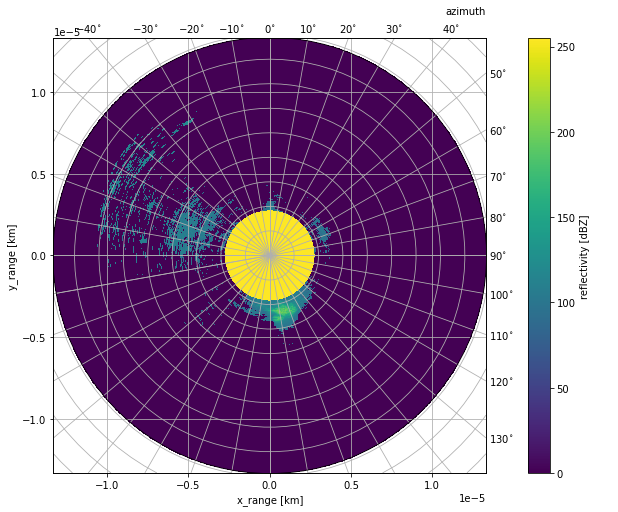

In [32]:
fig = pl.figure(figsize=(10, 8))
cgax, pm=im = wrl.vis.plot_ppi(fcontent['dataset1/data2/data'],
                      az=fcontent['dataset1/how']['startazA'], 
                      elev=fcontent['dataset1/how']['elangles'], 
                      #r=fcontent['dataset1/where']['nbins','nrays'], #this is not right
                      rf=fcontent['dataset1/where']['rstart']+fcontent['dataset1/where']['rscale']*fcontent['dataset1/where']['nbins']*1000, #this numbre is not right
                      site=sitio,
                      fig=fig, 
                      func='pcolormesh',
                      proj='cg') #cg stands for curvilinear grid

caax = cgax.parasites[0]
paax = cgax.parasites[1]

## To create the 
#pl.title('HERE SHOULD BE THE NAME OF THE FILE', y=1.05)
cbar = pl.colorbar(pm, pad=0.075, ax=paax)
caax.set_xlabel('x_range [km]')
caax.set_ylabel('y_range [km]')
pl.text(1.0, 1.05, 'azimuth', transform=caax.transAxes, va='bottom',
        ha='right')
cbar.set_label('reflectivity [dBZ]') #refelctivity only if we plat data2

To plot the dataset in a range of 15 km, that is a range closer to Popocatepetl:
# I need to reduce the matrix of the data to a 15 or 20 km range
# where['rscale'] Tamaño de las cajas
# where['rstart'] el prncipio de la medición
# where['nbins'] número de mediciones a lo largo del radio
# where['nrays'] número de mediciones a lo largo del ángulo

# Remember that although this function is PPI this data is not plane since it has an angle for each measurement but I have to confirm in the manual yet.
# I do need to transform the coordinates to a solid angle

In [8]:
# Change colors
# Plot the actual range that is 50 km. I cannot find that range in the file

In [47]:
print(fcontent['dataset2/how']) #This print a dictionary

{'elangles': array([4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5,
       4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5,
       4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5,
       4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5,
       4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5,
       4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5,
       4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5,
       4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5,
       4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5,
       4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5,
       4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5,
       4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5,
       4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5,
       4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5,

In [51]:
type(fcontent['dataset2/how']) #This is a dictionary

dict

In [60]:
type(fcontent['dataset2/how']['startazA'])#With this function we see all 238 angles

numpy.ndarray

In [59]:
type(fcontent['dataset1/data2/data']) #This is an array

numpy.ndarray

# How do I plot to 300 bins in the Axis669?

In [ ]:
En los eje se llama chunksizes que son los bins de cada dato
669 corresponde a 50 km empieza en cero y termina en 668 y va de 1 en 1
238 corresponde a 360 grados empieza en cero y termina en 237 y también va de 1 en 1.

Esos son los índices de los datos de salida.